# CIFAR-100 Image Classification

## Dataset Setup

### Library Imports

In [11]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

import plotly.graph_objects as go
from plotly.subplots import make_subplots

### Load Dataset

In [12]:
# Load in the data
cifar100 = keras.datasets.cifar100

# Distribute it to train and test set
(x_train, y_train), (x_val, y_val) = cifar100.load_data()
print(x_train.shape, y_train.shape, x_val.shape, y_val.shape)

(50000, 32, 32, 3) (50000, 1) (10000, 32, 32, 3) (10000, 1)


### Normalize Data

In [13]:
x_train = x_train / 255.0
x_val = x_val / 255.0

### Reshape Data

In [14]:
x_train = x_train.reshape((x_train.shape[0], 32, 32, 3))
x_val = x_val.reshape((x_val.shape[0], 32, 32, 3))

### One-Hot Encode Labels

In [15]:
y_train_one_hot = keras.utils.to_categorical(y_train, num_classes=100)
y_val_one_hot = keras.utils.to_categorical(y_val, num_classes=100)

### Verify Dataset Shape

In [16]:
print("Training images shape:", x_train.shape)
print("Validation images shape:", x_val.shape)
print("Training labels shape:", y_train_one_hot.shape)
print("Validation labels shape:", y_val_one_hot.shape)

Training images shape: (50000, 32, 32, 3)
Validation images shape: (10000, 32, 32, 3)
Training labels shape: (50000, 100)
Validation labels shape: (10000, 100)


## Model Building

### Basic ANN Model

In [17]:
ann_model = keras.Sequential([
    keras.layers.Flatten(input_shape=(32, 32, 3)),
    keras.layers.Dense(512, activation='relu'),
    keras.layers.Dense(256, activation='relu'),
    keras.layers.Dense(100, activation='softmax')  # 100 classes for CIFAR-100
])

ann_model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

ann_model.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 100)            │        25,700 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,730,404 (6.60 MB)

 Trainable params: 1,730,404 (6.60 MB)

 Non-trainable params: 0 (0.00 B)

### Basic CNN Model

In [18]:
basic_cnn_model = keras.Sequential([
    keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Conv2D(64, (3, 3), activation='relu'),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(100, activation='softmax')  # 100 classes for CIFAR-100
])

basic_cnn_model.compile(optimizer='adam',
                        loss='categorical_crossentropy',
                        metrics=['accuracy'])

basic_cnn_model.summary()


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 100)            │        12,900 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 327,332 (1.25 MB)

 Trainable params: 327,332 (1.25 MB)

 Non-trainable params: 0 (0.00 B)

### Deeper CNN Model

In [19]:
deeper_cnn_model = keras.Sequential([
    keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Dropout(0.25),

    keras.layers.Conv2D(64, (3, 3), activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Dropout(0.25),

    keras.layers.Conv2D(128, (3, 3), activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Dropout(0.25),

    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.5),

    keras.layers.Dense(100, activation='softmax')  # 100 classes for CIFAR-100
])

deeper_cnn_model.compile(optimizer='adam',
                         loss='categorical_crossentropy',
                         metrics=['accuracy'])

deeper_cnn_model.summary()


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 13, 13, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 4, 4, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 100)            │        12,900 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 173,220 (676.64 KB)

 Trainable params: 172,516 (673.89 KB)

 Non-trainable params: 704 (2.75 KB)

## Train Model

### Training ANN Model

In [20]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

model_checkpoint_ann = keras.callbacks.ModelCheckpoint(
    filepath='best_ann_model_weights.weights.h5',
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=True,
    mode='min',
    verbose=1
)

print("Training ANN model...")
ann_history = ann_model.fit(
    x_train,
    y_train_one_hot,
    epochs=30,
    batch_size=64,
    validation_data=(x_val, y_val_one_hot),
    callbacks=[early_stopping, model_checkpoint_ann]
)
print("ANN model training finished.")


Training ANN model...
Epoch 1/30
780/782 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.0505 - loss: 4.3174
Epoch 1: val_loss improved from inf to 3.79780, saving model to best_ann_model_weights.weights.h5
782/782 ━━━━━━━━━━━━━━━━━━━━ 29s 33ms/step - accuracy: 0.0506 - loss: 4.3165 - val_accuracy: 0.1173 - val_loss: 3.7978
Epoch 2/30
781/782 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.1361 - loss: 3.7069
Epoch 2: val_loss improved from 3.79780 to 3.61397, saving model to best_ann_model_weights.weights.h5
782/782 ━━━━━━━━━━━━━━━━━━━━ 24s 31ms/step - accuracy: 0.1361 - loss: 3.7068 - val_accuracy: 0.1562 - val_loss: 3.6140
Epoch 3/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.1604 - loss: 3.5418
Epoch 3: val_loss improved from 3.61397 to 3.51405, saving model to best_ann_model_weights.weights.h5
782/782 ━━━━━━━━━━━━━━━━━━━━ 25s 31ms/step - accuracy: 0.1604 - loss: 3.5418 - val_accuracy: 0.1727 - val_loss: 3.5140
Epoch 4/30
780/782 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - acc

### Training CNN Model

In [21]:
model_checkpoint_basic_cnn = keras.callbacks.ModelCheckpoint(
    filepath='best_basic_cnn_model_weights.weights.h5',
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=True,
    mode='min',
    verbose=1
)

print("Training Basic CNN model...")
basic_cnn_history = basic_cnn_model.fit(
    x_train,
    y_train_one_hot,
    epochs=30,
    batch_size=64,
    validation_data=(x_val, y_val_one_hot),
    callbacks=[early_stopping, model_checkpoint_basic_cnn]
)
print("Basic CNN model training finished.")

Training Basic CNN model...
Epoch 1/30
781/782 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.0751 - loss: 4.1240
Epoch 1: val_loss improved from inf to 3.33370, saving model to best_basic_cnn_model_weights.weights.h5
782/782 ━━━━━━━━━━━━━━━━━━━━ 69s 87ms/step - accuracy: 0.0752 - loss: 4.1231 - val_accuracy: 0.2006 - val_loss: 3.3337
Epoch 2/30
781/782 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.2297 - loss: 3.1838
Epoch 2: val_loss improved from 3.33370 to 3.03780, saving model to best_basic_cnn_model_weights.weights.h5
782/782 ━━━━━━━━━━━━━━━━━━━━ 82s 86ms/step - accuracy: 0.2297 - loss: 3.1836 - val_accuracy: 0.2568 - val_loss: 3.0378
Epoch 3/30
781/782 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.3007 - loss: 2.8141
Epoch 3: val_loss improved from 3.03780 to 2.85643, saving model to best_basic_cnn_model_weights.weights.h5
782/782 ━━━━━━━━━━━━━━━━━━━━ 85s 91ms/step - accuracy: 0.3007 - loss: 2.8140 - val_accuracy: 0.2968 - val_loss: 2.8564
Epoch 4/30
781/782 ━━━━━━━━━━━━━━━

### Training Deeper CNN Model

In [22]:
model_checkpoint_deeper_cnn = keras.callbacks.ModelCheckpoint(
    filepath='best_deeper_cnn_model_weights.weights.h5',
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=True,
    mode='min',
    verbose=1
)

print("Training Deeper CNN model...")
deeper_cnn_history = deeper_cnn_model.fit(
    x_train,
    y_train_one_hot,
    epochs=30,
    batch_size=64,
    validation_data=(x_val, y_val_one_hot),
    callbacks=[early_stopping, model_checkpoint_deeper_cnn]
)
print("Deeper CNN model training finished.")

Training Deeper CNN model...
Epoch 1/30
781/782 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - accuracy: 0.0554 - loss: 4.5686
Epoch 1: val_loss improved from inf to 3.55217, saving model to best_deeper_cnn_model_weights.weights.h5
782/782 ━━━━━━━━━━━━━━━━━━━━ 117s 144ms/step - accuracy: 0.0554 - loss: 4.5675 - val_accuracy: 0.1708 - val_loss: 3.5522
Epoch 2/30
781/782 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - accuracy: 0.1505 - loss: 3.5815
Epoch 2: val_loss improved from 3.55217 to 3.41365, saving model to best_deeper_cnn_model_weights.weights.h5
782/782 ━━━━━━━━━━━━━━━━━━━━ 142s 144ms/step - accuracy: 0.1505 - loss: 3.5813 - val_accuracy: 0.1832 - val_loss: 3.4136
Epoch 3/30
781/782 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - accuracy: 0.2049 - loss: 3.2725
Epoch 3: val_loss did not improve from 3.41365
782/782 ━━━━━━━━━━━━━━━━━━━━ 113s 144ms/step - accuracy: 0.2049 - loss: 3.2724 - val_accuracy: 0.1663 - val_loss: 3.4651
Epoch 4/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - accuracy: 0.2470 - loss: 3.

## Model Evalution

/tmp/ipython-input-3810418129.py:42: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


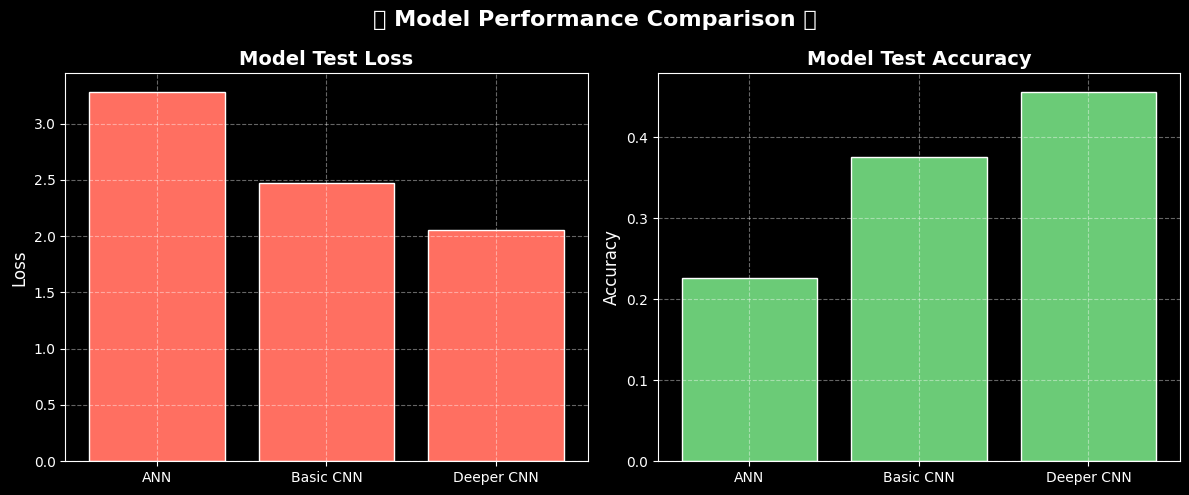

In [23]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

ann_model.load_weights('best_ann_model_weights.weights.h5')
basic_cnn_model.load_weights('best_basic_cnn_model_weights.weights.h5')
deeper_cnn_model.load_weights('best_deeper_cnn_model_weights.weights.h5')

loss_ann, accuracy_ann = ann_model.evaluate(x_val, y_val_one_hot, verbose=0)
loss_basic_cnn, accuracy_basic_cnn = basic_cnn_model.evaluate(x_val, y_val_one_hot, verbose=0)
loss_deeper_cnn, accuracy_deeper_cnn = deeper_cnn_model.evaluate(x_val, y_val_one_hot, verbose=0)


import matplotlib.pyplot as plt
import numpy as np

# Data
models = ['ANN', 'Basic CNN', 'Deeper CNN']
losses = [loss_ann, loss_basic_cnn, loss_deeper_cnn]
accuracies = [accuracy_ann, accuracy_basic_cnn, accuracy_deeper_cnn]

# Dark mode style
plt.style.use("dark_background")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Loss plot
axes[0].bar(models, losses, color='#FF6F61', edgecolor='white')
axes[0].set_title('Model Test Loss', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].grid(True, linestyle='--', alpha=0.4)

# Accuracy plot
axes[1].bar(models, accuracies, color='#6BCB77', edgecolor='white')
axes[1].set_title('Model Test Accuracy', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].grid(True, linestyle='--', alpha=0.4)

# Overall title
plt.suptitle("✨ Model Performance Comparison ✨", fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()


EXTRA

In [24]:
from sklearn.metrics import classification_report
y_val_true = np.argmax(y_val_one_hot, axis=1)

# Predictions
y_pred_ann = np.argmax(ann_model.predict(x_val), axis=1)
y_pred_basic_cnn = np.argmax(basic_cnn_model.predict(x_val), axis=1)
y_pred_deeper_cnn = np.argmax(deeper_cnn_model.predict(x_val), axis=1)

print("ANN Classification Report:")
print(classification_report(y_val_true, y_pred_ann))

print("Basic CNN Classification Report:")
print(classification_report(y_val_true, y_pred_basic_cnn))

print("Deeper CNN Classification Report:")
print(classification_report(y_val_true, y_pred_deeper_cnn))


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step
ANN Classification Report:
              precision    recall  f1-score   support

           0       0.53      0.43      0.48       100
           1       0.25      0.26      0.25       100
           2       0.18      0.17      0.17       100
           3       0.05      0.02      0.03       100
           4       0.08      0.06      0.07       100
           5       0.18      0.24      0.21       100
           6       0.25      0.15      0.19       100
           7       0.23      0.31      0.26       100
           8       0.26      0.22      0.24       100
           9       0.22      0.42      0.29       100
          10       0.11      0.04      0.06       100
          11       0.13      0.08      0.10       100
          12       0.23      0.19      0.21       100
          13       0.28      0.19      0.23       100
          14       0.20      0.19    

### Confusion Matrix & Report

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step


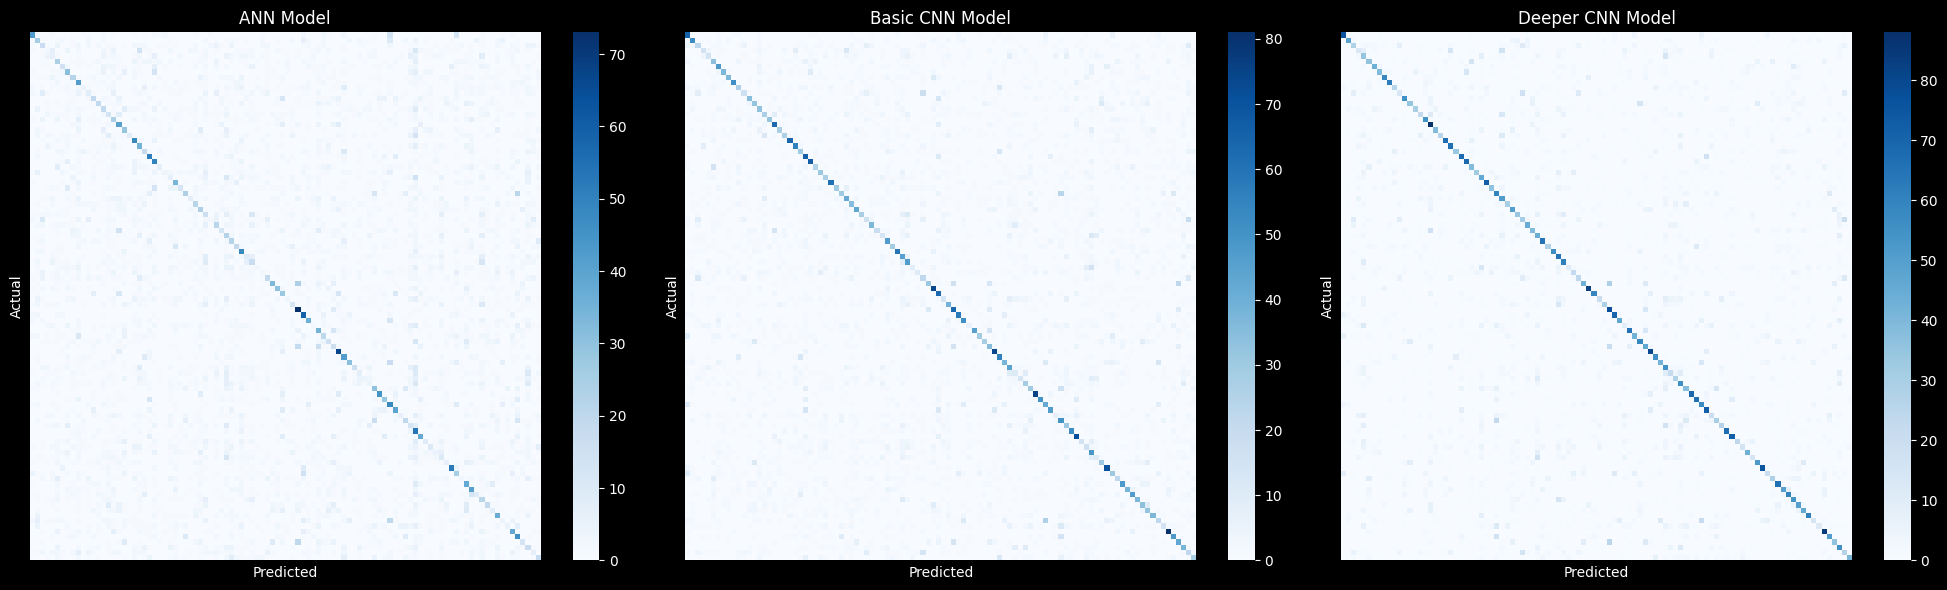

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Predictions
ann_predictions = ann_model.predict(x_val)
basic_cnn_predictions = basic_cnn_model.predict(x_val)
deeper_cnn_predictions = deeper_cnn_model.predict(x_val)

# Convert one-hot labels to integers
y_val_int = np.argmax(y_val_one_hot, axis=1)

# Convert predictions to integer labels
ann_predicted_labels = np.argmax(ann_predictions, axis=1)
basic_cnn_predicted_labels = np.argmax(basic_cnn_predictions, axis=1)
deeper_cnn_predicted_labels = np.argmax(deeper_cnn_predictions, axis=1)

# Confusion matrices
cm_ann = confusion_matrix(y_val_int, ann_predicted_labels)
cm_basic = confusion_matrix(y_val_int, basic_cnn_predicted_labels)
cm_deeper = confusion_matrix(y_val_int, deeper_cnn_predicted_labels)

# Plot side by side
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.heatmap(cm_ann, cmap="Blues", ax=axes[0])
axes[0].set_title("ANN Model")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")
axes[0].set_xticks([])
axes[0].set_yticks([])

sns.heatmap(cm_basic, cmap="Blues", ax=axes[1])
axes[1].set_title("Basic CNN Model")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")
axes[1].set_xticks([])
axes[1].set_yticks([])

sns.heatmap(cm_deeper, cmap="Blues", ax=axes[2])
axes[2].set_title("Deeper CNN Model")
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("Actual")
axes[2].set_xticks([])
axes[2].set_yticks([])

plt.tight_layout()
plt.show()


**Observation:**
Ah! That happens because CIFAR-100 has 100 classes, so confusion matrix is 100×100, and we are trying to display it all in a single figure. Matplotlib squeezes everything into the same plot area, so each square ends up tiny

### Model Comparision

In [26]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd

# Model histories and colors
models = {
    "ANN": ("cyan", ann_history),
    "Basic CNN": ("magenta", basic_cnn_history),
    "Deeper CNN": ("yellow", deeper_cnn_history)
}

# Create subplots
fig = make_subplots(rows=1, cols=2, subplot_titles=('Accuracy', 'Loss'))

for name, (color, history) in models.items():
    # Training and Validation Accuracy
    fig.add_trace(go.Scatter(
        y=history.history['accuracy'],
        mode='lines',
        name=f"{name} Train",
        line=dict(color=color, dash='solid')
    ), row=1, col=1)

    fig.add_trace(go.Scatter(
        y=history.history['val_accuracy'],
        mode='lines',
        name=f"{name} Val",
        line=dict(color=color, dash='dot')
    ), row=1, col=1)

    # Training and Validation Loss
    fig.add_trace(go.Scatter(
        y=history.history['loss'],
        mode='lines',
        name=f"{name} Train",
        line=dict(color=color, dash='solid')
    ), row=1, col=2)

    fig.add_trace(go.Scatter(
        y=history.history['val_loss'],
        mode='lines',
        name=f"{name} Val",
        line=dict(color=color, dash='dot')
    ), row=1, col=2)

# Update layout
fig.update_layout(
    title_text="✨ Model Comparison: Accuracy & Loss (Train=Solid, Val=Dot) ✨",
    height=550,
    width=1200,
    template="plotly_dark"
)

fig.show()


### Prediction

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step


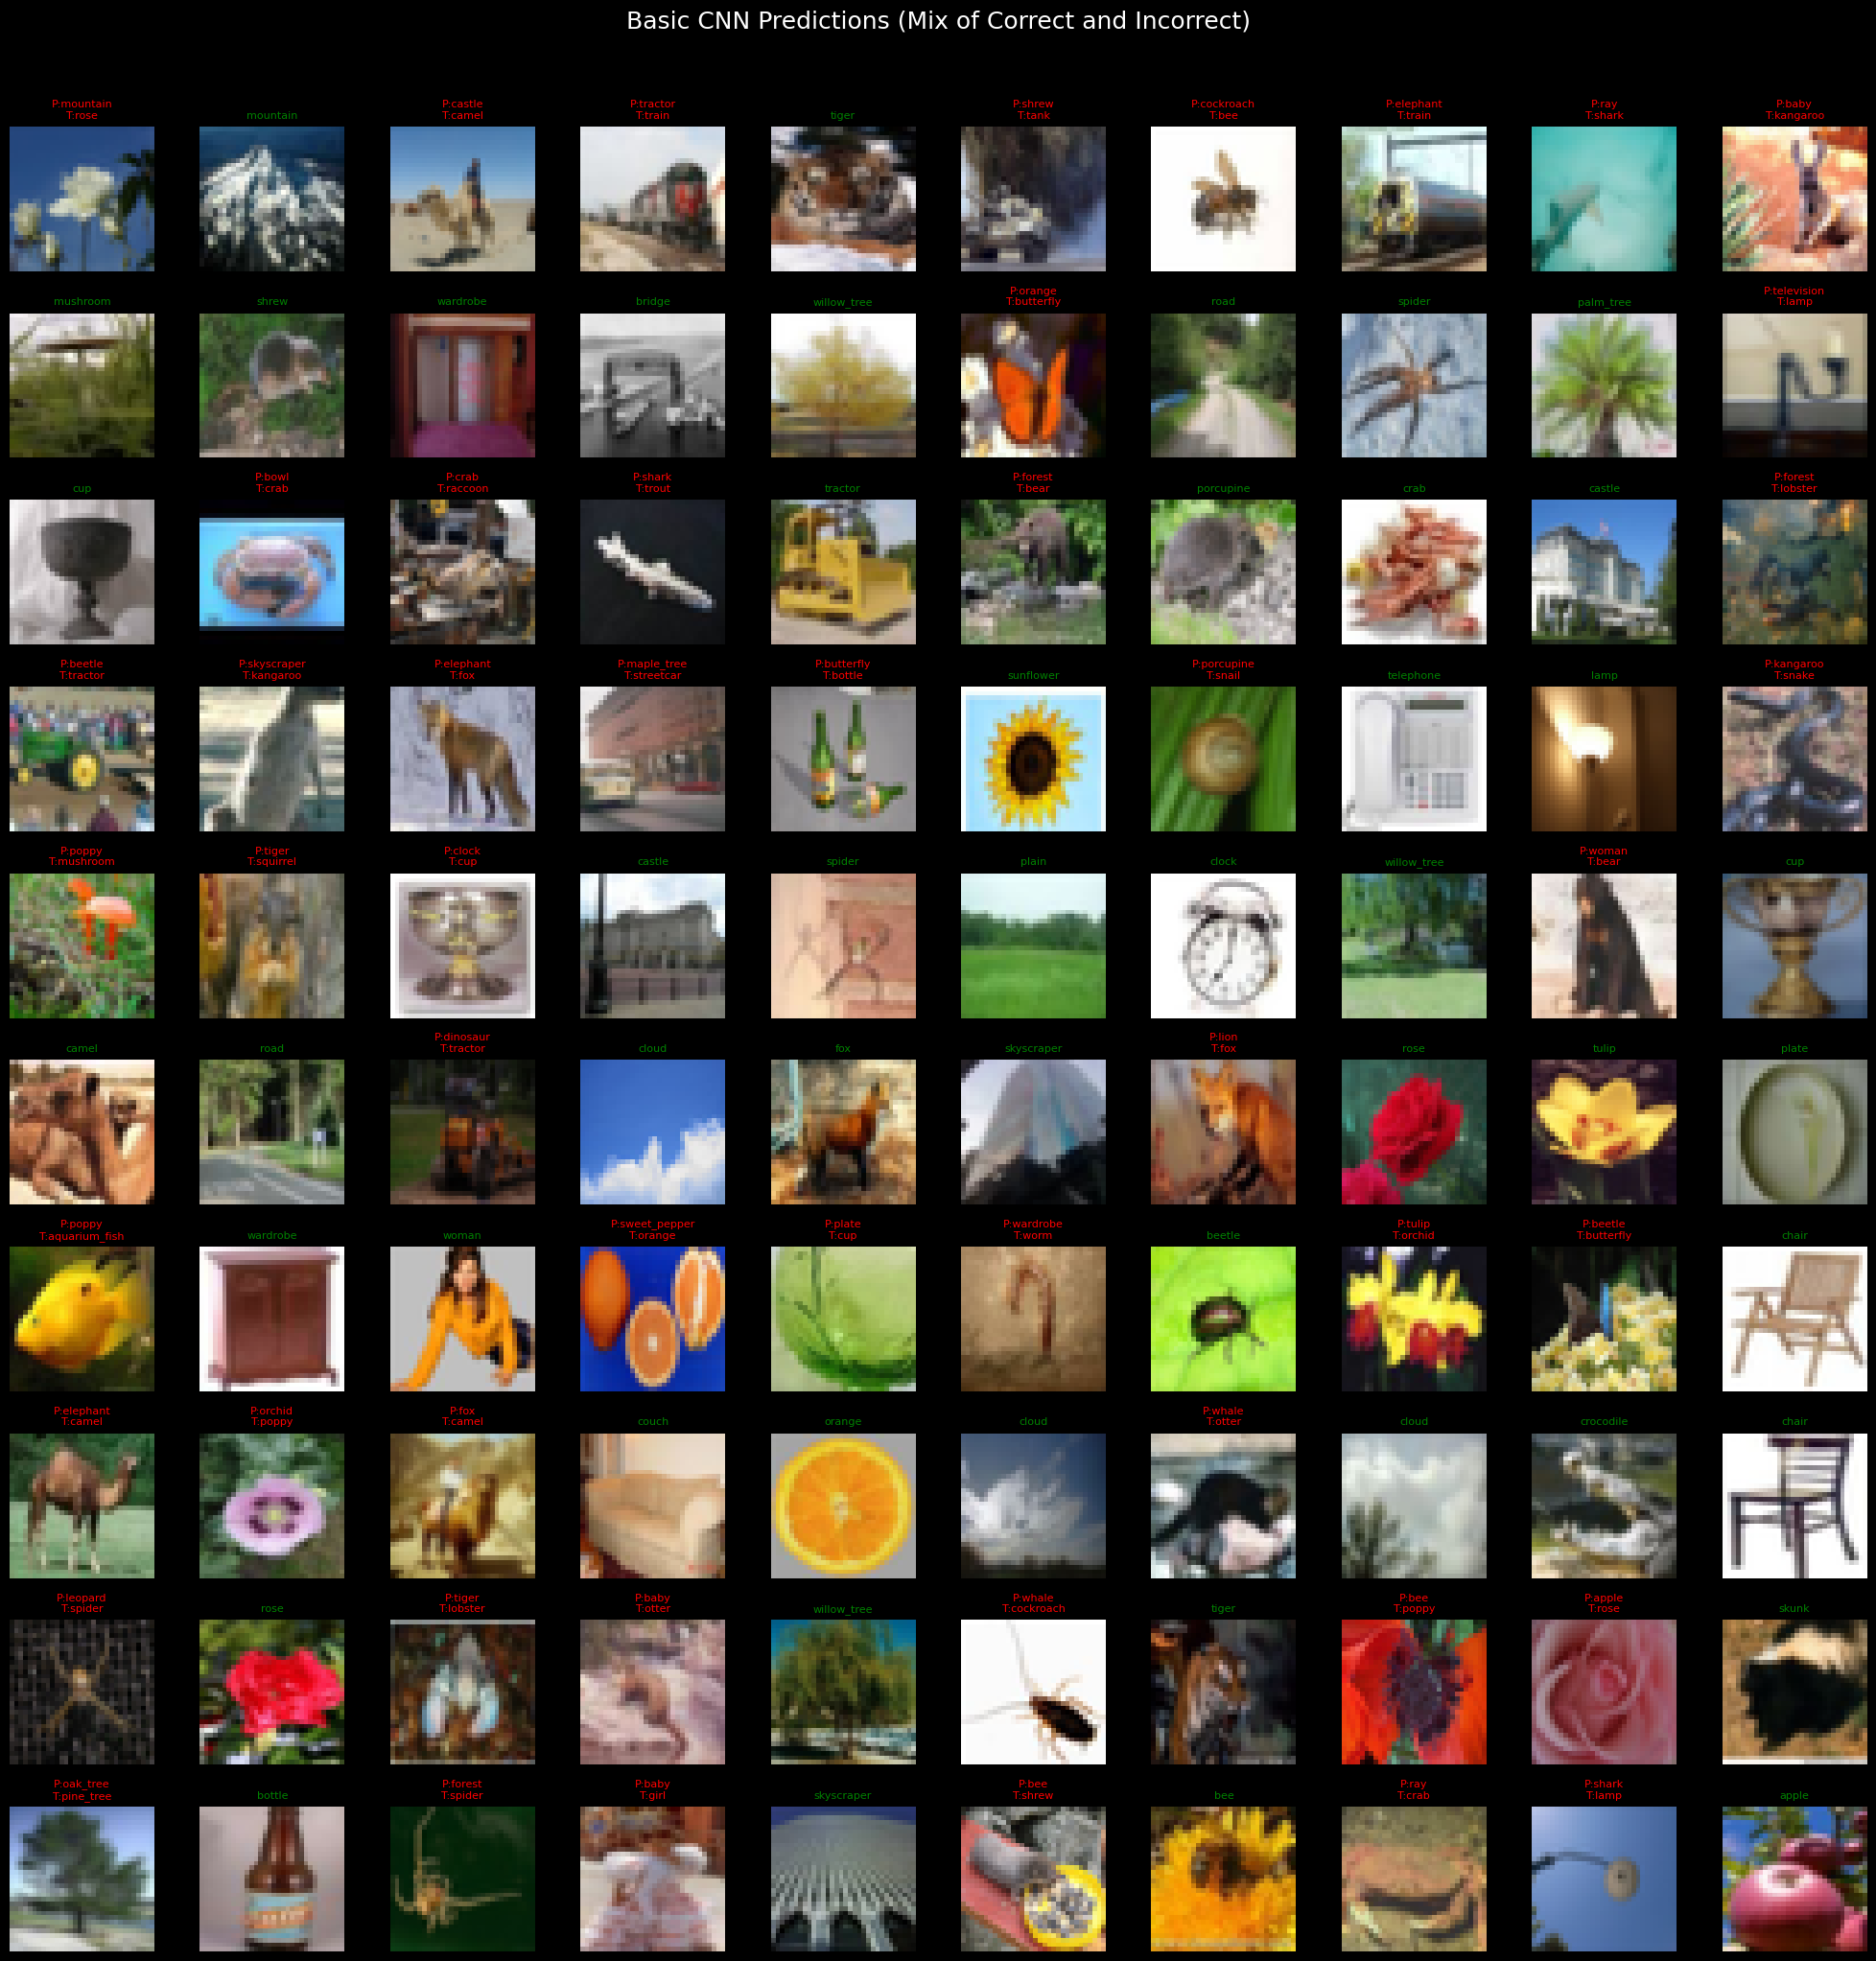

In [27]:
# Predictions
basic_cnn_predictions = basic_cnn_model.predict(x_val)
basic_cnn_predicted_labels = np.argmax(basic_cnn_predictions, axis=1)

# Convert one-hot labels to integers if needed
y_val_int = np.argmax(y_val_one_hot, axis=1)  # use x_val / y_val for validation

# Find correctly and incorrectly classified images
correctly_classified_indices = np.where(basic_cnn_predicted_labels == y_val_int)[0]
incorrectly_classified_indices = np.where(basic_cnn_predicted_labels != y_val_int)[0]

# CIFAR-100 class names
class_names = [
    'apple', 'aquarium_fish', 'baby', 'bear', 'beaver',
    'bed', 'bee', 'beetle', 'bicycle', 'bottle',
    'bowl', 'boy', 'bridge', 'bus', 'butterfly',
    'camel', 'can', 'castle', 'caterpillar', 'cattle',
    'chair', 'chimpanzee', 'clock', 'cloud', 'cockroach',
    'couch', 'crab', 'crocodile', 'cup', 'dinosaur',
    'dolphin', 'elephant', 'flatfish', 'forest', 'fox',
    'girl', 'hamster', 'house', 'kangaroo', 'keyboard',
    'lamp', 'lawn_mower', 'leopard', 'lion', 'lizard',
    'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain',
    'mouse', 'mushroom', 'oak_tree', 'orange', 'orchid',
    'otter', 'palm_tree', 'pear', 'pickup_truck', 'pine_tree',
    'plain', 'plate', 'poppy', 'porcupine', 'possum', 'rabbit',
    'raccoon', 'ray', 'road', 'rocket', 'rose',
    'sea', 'seal', 'shark', 'shrew', 'skunk',
    'skyscraper', 'snail', 'snake', 'spider', 'squirrel',
    'streetcar', 'sunflower', 'sweet_pepper', 'table',
    'tank', 'telephone', 'television', 'tiger', 'tractor',
    'train', 'trout', 'tulip', 'turtle', 'wardrobe',
    'whale', 'willow_tree', 'wolf', 'woman', 'worm'
]

# Select a mix
num_correct_to_show = min(50, len(correctly_classified_indices))
num_incorrect_to_show = min(50, len(incorrectly_classified_indices))

selected_correct_indices = np.random.choice(correctly_classified_indices, num_correct_to_show, replace=False)
selected_incorrect_indices = np.random.choice(incorrectly_classified_indices, num_incorrect_to_show, replace=False)

# Combine and shuffle
all_indices = np.concatenate((selected_correct_indices, selected_incorrect_indices))
np.random.shuffle(all_indices)

# Display images in a 10x10 grid
num_cols = 10
num_rows = 10

fig, axes = plt.subplots(num_rows, num_cols, figsize=(2*num_cols, 2*num_rows))
fig.suptitle("Basic CNN Predictions (Mix of Correct and Incorrect)", fontsize=18, y=1.02)

for i, idx in enumerate(all_indices[:num_rows*num_cols]):
    row = i // num_cols
    col = i % num_cols
    axes[row, col].imshow(x_val[idx])  # CIFAR images are RGB, shape (32,32,3)

    pred = class_names[basic_cnn_predicted_labels[idx]]
    true = class_names[y_val_int[idx]]

    if basic_cnn_predicted_labels[idx] == y_val_int[idx]:
        color = "green"
        title = f"{pred}"
    else:
        color = "red"
        title = f"P:{pred}\nT:{true}"

    axes[row, col].set_title(title, fontsize=8, color=color)
    axes[row, col].axis("off")

plt.tight_layout()
plt.show()


## Conclusion

This project compared an **ANN**, a **Basic CNN**, and a **Deeper CNN** on the CIFAR-100 dataset.

- The **ANN** performed the weakest, as it couldn’t capture spatial image features.  
- The **Basic CNN** improved accuracy by learning visual patterns.  
- The **Deeper CNN** achieved the **best performance**, thanks to additional layers, batch normalization, and dropout.

👉 Overall, deeper convolutional networks clearly outperform simple neural networks for image classification, highlighting the importance of **depth and feature extraction** in computer vision tasks.
